In [2]:

from pathlib import Path

import uproot
import awkward as ak
from coffea import nanoevents

import numpy as np

import matplotlib.pyplot as plt
import mplhep as hep
from matplotlib import colors

from boostedhh.processors.utils import GEN_FLAGS, PDGID, pad_val

from boostedhh.processors.utils import (
    GEN_FLAGS,
    P4,
    PDGID,
    add_selection,
    pad_val,
)

In [3]:
# automatically reloads imported files on edits
%load_ext autoreload
%autoreload 2
MAIN_DIR = Path("../../")

plot_dir = MAIN_DIR / "plots/TriggerStudy/24Nov6"
plot_dir.mkdir(parents=True, exist_ok=True)
events = nanoevents.NanoEventsFactory.from_root(
    "root://cmseos.fnal.gov//store/user/lpcdihiggsboost/NanoAOD_v12_ParT/rkansal/2022/HHbbtt/GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_powheg-pythia8/GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_TuneCP5_13p6TeV/241028_235514/0000/Run3Summer22NanoAODv12_1-1.root", # reads a .root file
    schemaclass=nanoevents.NanoAODSchema,
).events()

TLS: Unable to use cert+key file /uscms/home/adas1/x509up_u14222; does not exist.


In [4]:
!xrdfs root://cmseos.fnal.gov ls -R /store/user/lpcdihiggsboost/NanoAOD_v12_ParT/rkansal/2022/HHbbtt/GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_powheg-pythia8/GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_TuneCP5_13p6TeV/241028_235514/0000/


TLS: Unable to use cert+key file /uscms/home/adas1/x509up_u14222; does not exist.
/store/user/lpcdihiggsboost/NanoAOD_v12_ParT/rkansal/2022/HHbbtt/GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_powheg-pythia8/GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_TuneCP5_13p6TeV/241028_235514/0000/Run3Summer22NanoAODv12_1-1.root
/store/user/lpcdihiggsboost/NanoAOD_v12_ParT/rkansal/2022/HHbbtt/GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_powheg-pythia8/GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_TuneCP5_13p6TeV/241028_235514/0000/Run3Summer22NanoAODv12_1-10.root
/store/user/lpcdihiggsboost/NanoAOD_v12_ParT/rkansal/2022/HHbbtt/GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_powheg-pythia8/GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_TuneCP5_13p6TeV/241028_235514/0000/Run3Summer22NanoAODv12_1-11.root
/store/user/lpcdihiggsboost/NanoAOD_v12_ParT/rkansal/2022/HHbbtt/GluGlutoHHto2B2Tau_kl-1p00_kt-1p00_c2-0p00_LHEweights_TuneCP5_13p6TeV_p

In [5]:
np.min(ak.flatten(ak.firsts(events.FatJet.pt), axis=None))
# plt.hist(
#     ak.flatten(ak.firsts(events.FatJet.pt), axis=None), np.linspace(0, 1000, 101), histtype="step"
# )
events.HLT.fields


['AK8PFJet360_TrimMass30',
 'AK8PFJet380_TrimMass30',
 'AK8PFJet400_TrimMass30',
 'AK8PFJet420_TrimMass30',
 'AK8PFJet400_MassSD30',
 'AK8PFJet420_MassSD30',
 'AK8PFJet450_MassSD30',
 'AK8DiPFJet250_250_MassSD30',
 'AK8DiPFJet250_250_MassSD50',
 'AK8DiPFJet260_260_MassSD30',
 'AK8DiPFJet270_270_MassSD30',
 'AK8PFHT750_TrimMass50',
 'AK8PFHT800_TrimMass50',
 'AK8PFHT850_TrimMass50',
 'AK8PFHT900_TrimMass50',
 'CaloJet500_NoJetID',
 'CaloJet550_NoJetID',
 'DoubleMu5_Upsilon_DoubleEle3_CaloIdL_TrackIdL',
 'DoubleMu3_DoubleEle7p5_CaloIdL_TrackIdL_Upsilon',
 'Trimuon5_3p5_2_Upsilon_Muon',
 'TrimuonOpen_5_3p5_2_Upsilon_Muon',
 'DoubleEle25_CaloIdL_MW',
 'DoubleEle27_CaloIdL_MW',
 'DoubleEle33_CaloIdL_MW',
 'DoubleEle24_eta2p1_WPTight_Gsf',
 'DoubleEle8_CaloIdM_TrackIdM_Mass8_DZ_PFHT350',
 'DoubleEle8_CaloIdM_TrackIdM_Mass8_PFHT350',
 'Ele27_Ele37_CaloIdL_MW',
 'Mu27_Ele37_CaloIdL_MW',
 'Mu37_Ele27_CaloIdL_MW',
 'Mu37_TkMu27',
 'DoubleMu4_3_Bs',
 'DoubleMu4_3_Jpsi',
 'DoubleMu4_3_LowMass',
 '

In [6]:
events.FatJet.fields

['jetId',
 'nConstituents',
 'subJetIdx1',
 'subJetIdx2',
 'electronIdx3SJ',
 'muonIdx3SJ',
 'nConstChHads',
 'nConstElecs',
 'nConstHFEMs',
 'nConstHFHads',
 'nConstMuons',
 'nConstNeuHads',
 'nConstPhotons',
 'area',
 'btagDDBvLV2',
 'btagDDCvBV2',
 'btagDDCvLV2',
 'btagDeepB',
 'btagHbb',
 'chEmEF',
 'chHEF',
 'eta',
 'globalParT_QCD0HF',
 'globalParT_QCD1HF',
 'globalParT_QCD2HF',
 'globalParT_TopW',
 'globalParT_TopbW',
 'globalParT_TopbWev',
 'globalParT_TopbWmv',
 'globalParT_TopbWq',
 'globalParT_TopbWqq',
 'globalParT_TopbWtauhv',
 'globalParT_Xbb',
 'globalParT_XbbVsQCD',
 'globalParT_Xcc',
 'globalParT_Xcs',
 'globalParT_Xgg',
 'globalParT_Xqq',
 'globalParT_Xtauhtaue',
 'globalParT_Xtauhtauh',
 'globalParT_Xtauhtaum',
 'globalParT_massRes',
 'globalParT_massVis',
 'hfEmEF',
 'hfHEF',
 'mass',
 'msoftdrop',
 'muEF',
 'n2b1',
 'n3b1',
 'neEmEF',
 'neHEF',
 'particleNetLegacy_QCD',
 'particleNetLegacy_QCDb',
 'particleNetLegacy_QCDbb',
 'particleNetLegacy_QCDc',
 'particleNetL

In [7]:
def print_event_tree(obj, name="events", indent="", max_depth=4, depth=0):
    """
    Recursively prints the structure of a NanoAOD event tree.
    
    Parameters:
    - obj: The Awkward array or object to inspect.
    - name: Current name or label to print.
    - indent: Indentation level (used internally).
    - max_depth: How deep to go into nested structures.
    - depth: Internal counter to track recursion.
    """
    # Safety against infinite recursion
    if depth > max_depth:
        print(f"{indent}{name}: <Max depth reached>")
        return

    try:
        fields = obj.fields
    except Exception:
        fields = []

    # Print collection name/type
    typename = type(obj).__name__
    print(f"{indent}{name} ({typename})")

    # If there are fields, go deeper
    for field in fields:
        sub = getattr(obj, field)
        print_event_tree(sub, name=field, indent=indent + "  ", 
                         max_depth=max_depth, depth=depth + 1)

print_event_tree(events, name="events", indent="", max_depth=4, depth=2)

events (NanoEventsArray)
  event (Array)
  TrigObj (PtEtaPhiMCollectionArray)
    l1charge (Array)
    id (Array)
    l1iso (Array)
    filterBits (Array)
    pt (Array)
    eta (Array)
    phi (Array)
    l1pt (Array)
    l1pt_2 (Array)
    l2pt (Array)
  JetCalo (NanoCollectionArray)
    area (Array)
    emf (Array)
    eta (Array)
    mass (Array)
    phi (Array)
    pt (Array)
    rawFactor (Array)
    genJetIdx (Array)
    hadronFlavour (Array)
    partonFlavour (Array)
  HLT (NanoCollectionArray)
    AK8PFJet360_TrimMass30 (Array)
    AK8PFJet380_TrimMass30 (Array)
    AK8PFJet400_TrimMass30 (Array)
    AK8PFJet420_TrimMass30 (Array)
    AK8PFJet400_MassSD30 (Array)
    AK8PFJet420_MassSD30 (Array)
    AK8PFJet450_MassSD30 (Array)
    AK8DiPFJet250_250_MassSD30 (Array)
    AK8DiPFJet250_250_MassSD50 (Array)
    AK8DiPFJet260_260_MassSD30 (Array)
    AK8DiPFJet270_270_MassSD30 (Array)
    AK8PFHT750_TrimMass50 (Array)
    AK8PFHT800_TrimMass50 (Array)
    AK8PFHT850_TrimMass50 (Ar

In [8]:
for field in events.fields:
    print(field)

print("="*100)
print("="*100)
print("Arranged in order:")
print("="*100)
print("="*100)
for field in sorted(events.fields):
    print(field)



event
TrigObj
JetCalo
HLT
DeepMETResponseTune
HLTriggerFirstPath
boostedTau
LHE
SoftActivityJetNjets5
CaloMET
PV
CorrT1METJet
PSWeight
GenJetAK8
SoftActivityJetHT2
DeepMETResolutionTune
SoftActivityJetNjets2
FatJetForJEC
LowPtElectron
SubJet
SubGenJetAK8
GenMET
genWeight
Photon
HTXS
Electron
OtherPV
GenVisTau
Rho
L1simulation
Jet
Generator
HLTriggerFinalPath
LHEReweightingWeight
L1
RawPuppiMET
Flag
GenProton
BeamSpot
Tau
run
GenJet
L1Reco
RawMET
SV
PuppiMET
SoftActivityJetHT5
GenIsolatedPhoton
LHEScaleWeight
genTtbarId
LHEPdfWeight
GenPart
ChsMET
GenJetAK8ForJEC
FsrPhoton
Muon
luminosityBlock
TkMET
JetCHS
SoftActivityJetHT10
GenVtx
MET
SoftActivityJetHT
SoftActivityJetNjets10
LHEPart
GenDressedLepton
bunchCrossing
Pileup
SoftActivityJet
FatJetCHS
FatJet
LHEWeight
IsoTrack
Arranged in order:
BeamSpot
CaloMET
ChsMET
CorrT1METJet
DeepMETResolutionTune
DeepMETResponseTune
Electron
FatJet
FatJetCHS
FatJetForJEC
Flag
FsrPhoton
GenDressedLepton
GenIsolatedPhoton
GenJet
GenJetAK8
GenJetAK8ForJ

In [9]:
events.metadata

{'version': 'latest'}

In [10]:
events.Tau.idDeepTau2018v2p5VSe

<Array [[3, 5, 7], [0], ... 0], [8, 0], [8]] type='25300 * var * uint8[parameter...'>

In [11]:
print(events.Tau.idDeepTau2017v2p1VSe) 
print(events.Tau.idDeepTau2017v2p1VSmu)
print(events.Tau.idDeepTau2017v2p1VSjet)


[[4, 5, 7], [0], [8, 8], [], [3, 8], [4, 8, ... 8], [8], [8, 8], [8, 8], [8, 6], [8]]
[[4, 4, 4], [3], [4, 4], [], [4, 4], [4, 4, ... 4], [4], [4, 4], [0, 0], [4, 0], [4]]
[[8, 0, 8], [8], [8, 7], [], [0, 8], [8, 4, ... 7], [8], [8, 5], [8, 8], [5, 8], [7]]


In [12]:
print(events.Muon.tightId) 
print(events.Muon.mediumId)   
print(events.Muon.looseId)  

[[], [False, False], [], [True, True], ... [], [True, True], [True], [True]]
[[], [False, True], [], [True, True], [True, ... [], [True, True], [True], [True]]
[[], [True, True], [], [True, True], [True, ... [], [], [True, True], [True], [True]]


In [13]:
genparts = events.GenPart[events.GenPart.hasFlags(GEN_FLAGS)]
higgs = genparts[genparts.pdgId == PDGID.H]
higgs_children = higgs.children
bb = higgs_children[np.abs(higgs_children.pdgId) == PDGID.b]
taus = higgs_children[np.abs(higgs_children.pdgId) == PDGID.tau]
tau_children = ak.flatten(taus.children, axis=2)

# finding bb and VV children
is_bb = np.abs(higgs_children.pdgId) == PDGID.b
is_tt = np.abs(higgs_children.pdgId) == PDGID.tau

# checking that there are 2 bs and 2 taus
has_bb = ak.sum(ak.flatten(is_bb, axis=2), axis=1) == 2
has_tt = ak.sum(ak.flatten(is_tt, axis=2), axis=1) == 2

In [14]:
for _ in is_bb:
    print(_)

[[False, False], [True, True]]
[[False, False], [True, True]]
[[True, True], [False, False]]
[[True, True], [False, False]]
[[False, False], [True, True]]
[[True, True], [False, False]]
[[True, True], [False, False]]
[[False, False], [True, True]]
[[False, False], [True, True]]
[[True, True], [False, False]]
[[False, False], [True, True]]
[[True, True], [False, False]]
[[False, False], [True, True]]
[[True, True], [False, False]]
[[True, True], [False, False]]
[[False, False], [True, True]]
[[True, True], [False, False]]
[[False, False], [True, True]]
[[False, False], [True, True]]
[[True, True], [False, False]]
[[True, True], [False, False]]
[[False, False], [True, True]]
[[False, False], [True, True]]
[[True, True], [False, False]]
[[True, True], [False, False]]
[[True, True], [False, False]]
[[False, False], [True, True]]
[[False, False], [True, True]]
[[True, True], [False, False]]
[[True, True], [False, False]]
[[False, False], [True, True]]
[[False, False], [True, True]]
[[True, 

In [22]:
1+1

2

In [27]:
events.Jet.genJetIdx

<Array [[0, 1, 2, 4, 3, ... -1, -1, -1, -1]] type='25300 * var * int16[parameter...'>

In [15]:
def good_taus(taus):
    # Example selection: pT > 20, |eta| < 2.3, etc.
    return taus[(taus.pt > 20) & (abs(taus.eta) < 2.3)]

def good_electrons(electrons):
    return electrons[(electrons.pt > 10) & (abs(electrons.eta) < 2.5)]

def good_muons(muons):
    return muons[(muons.pt > 10) & (abs(muons.eta) < 2.4)]

def good_boostedtaus(btaus):
    return btaus[(btaus.pt > 20) & (abs(btaus.eta) < 2.3)]


In [13]:
genparts

<GenParticleArray [[GenParticle, ... GenParticle]] type='25300 * var * genParticle'>

In [14]:
print(higgs_children.pdgId)
print(np.abs(higgs_children.pdgId))
print(np.abs(higgs_children.pdgId) == PDGID.b)

[[[15, -15], [5, -5]], [[15, -15], [5, -5, ... -5], [15, -15]], [[5, -5], [15, -15]]]
[[[15, 15], [5, 5]], [[15, 15], [5, 5]], ... [[5, 5], [15, 15]], [[5, 5], [15, 15]]]
[[[False, False], [True, True]], [[False, ... [[True, True], [False, False]]]


In [15]:
taus.children.pdgId

<Array [[[[15, 22], ... 111, 111, 211]]]] type='25300 * var * var * option[var *...'>

In [16]:
for children in taus.childrenIdxG: 
    print(children) 

[[[16, 17], [18]], []]
[[[94, 95, 96, 97], [91, 92, 93]], []]
[[], [[138, 139], [140]]]
[[], [[220, 221, 222], [217, 218, 219]]]
[[[259, 260], [261]], []]
[[], [[347, 348, 349, 350, 351], [343, 344, 345, 346]]]
[[], [[405, 406, 407], [402, 403, 404]]]
[[[450, 451, 452], [447, 448, 449]], []]
[[[478], [476, 477]], []]
[[], [[533, 534], [535]]]
[[[600, 601, 602], [596, 597, 598, 599]], []]
[[], [[631, 636], [632]]]
[[[705], [703, 704]], []]
[[], [[779], [777, 778]]]
[[], [[835, 836], [837]]]
[[[917], [915, 916]], []]
[[], [[981], [979, 980]]]
[[[1057, 1058], [1054, 1055, 1056]], []]
[[[1099, 1100], [1101]], []]
[[], [[1173, 1174], [1175]]]
[[], [[1233, 1234, 1235], [1236, 1237]]]
[[[1281, 1282, 1283, 1284], [1285, 1286, 1287, 1288, 1289]], []]
[[[1338, 1339, 1340], [1341, 1342, 1343]], []]
[[], [[1389], [1387, 1388]]]
[[], [[1464, 1465], [1466]]]
[[], [[1543, 1544], [1545]]]
[[[1604], [1602, 1603]], []]
[[[1662, 1663, 1664], [1665, 1666, 1667]], []]
[[], [[1707, 1708], [1709]]]
[[], [[17

[[[148122], [148120, 148121]], []]
[[], [[148211, 148212, 148213], [148207, 148208, 148209, 148210]]]
[[[148246], [148244, 148245, 148247, 148248, 148251]], []]
[[[148328, 148329], [148330, 148331, 148332]], []]
[[[148374, 148375, 148376], [148371, 148372, 148373]], []]
[[[148412], [148411, 148415]], []]
[[], [[148478], [148476, 148477]]]
[[[148542, 148543, 148544], [148540, 148541]], []]
[[[148595, 148596, 148597], [148598, 148599, 148600]], []]
[[], [[148654, 148655, 148656], [148651, 148652, 148653]]]
[[], [[148717, 148718, 148719], [148715, 148716]]]
[[], [[148781, 148782, 148783], [148778, 148779, 148780]]]
[[], [[148835, 148836], [148832, 148833, 148834]]]
[[[148881, 148882, 148883, 148884], [148885, 148886, 148887]], []]
[[], [[148934, 148935, 148936], [148937]]]
[[], [[148993, 148994, 148995, 148996], [148990, 148991, 148992]]]
[[], [[149029], [149027, 149028]]]
[[], [[149095], [149093, 149094]]]
[[], [[149160, 149161], [149162]]]
[[], [[149257, 149258, 149259, 149260, 149261],

In [17]:
for (var, key) in P4.items():
    print(var, key)

eta Eta
phi Phi
mass Mass
pt Pt


In [18]:
len(events)

25300

In [19]:
PDGID.H

25

In [63]:
set(np.array(genparts.pdgId[0]))

{-15, -5, 5, 15, 21, 25}

In [64]:

ak.any(ak.is_none(higgs_children.pdgId[:, :, 0]))
ak.flatten(bb.pt, axis=2).to_numpy().data
pad_val(ak.flatten(bb.pt, axis=2), 2, axis=1)
pad_val(higgs_children.pdgId[:, :, 0], 2, axis=1)

array([[15,  5],
       [15,  5],
       [ 5, 15],
       ...,
       [15,  5],
       [ 5, 15],
       [ 5, 15]])

In [9]:
# iterate through the children in photon scattering events to get final daughter particles
for i in range(5):
    tau_mask = ak.any(np.abs(tau_children.pdgId) == PDGID.tau, axis=2)
    if not ak.any(tau_mask):
        print(f"Done after {i} iterations")
        break

    tau_children_children = ak.flatten(
        tau_children[np.abs(tau_children.pdgId) == PDGID.tau].children, axis=3
    )

    # use a where condition to get next layer of children for photon scattering events
    tau_children = ak.where(tau_mask, tau_children_children, tau_children)

Done after 2 iterations


In [ ]:
def _sum_taus(taut):
    return ak.sum(taut, axis=1)


# check neutral and charged pion IDs for hadronic taus
tauh = _sum_taus(
    ak.any([ak.any(np.abs(tau_children.pdgId) == pid, axis=2) for pid in PDGID.pions], axis=0)
)
taumu = _sum_taus(ak.any(np.abs(tau_children.pdgId) == PDGID.mu, axis=2))
taue = _sum_taus(ak.any(np.abs(tau_children.pdgId) == PDGID.e, axis=2))

tauhh = tauh == 2
tauhmu = (tauh == 1) & (taumu == 1)
tauhe = (tauh == 1) & (taue == 1)

In [11]:
mhh = (higgs[:, 0] + higgs[:, 1]).mass.to_numpy()
weights = events.genWeight.to_numpy()

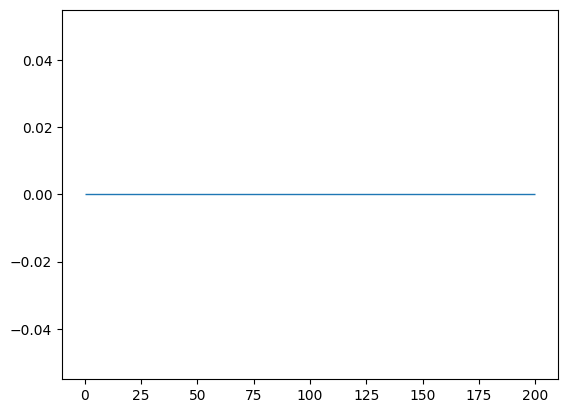

In [12]:
plt.hist(mhh[tauhh], np.linspace(0, 200, 101), histtype="step")
plt.show()
